In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pickle


In [36]:
data = pd.read_csv("E:\HousePricePrediction\HousePriceDataset.csv")
data.head()

,MS SubClass,MS Zoning,Lot Area,Neighborhood,Overall Qual,Year Built,Gr Liv Area,Bsmt Full Bath,Full Bath,Bedroom AbvGr,Garage Cars,Garage Area,SalePrice
0,20,RL,31770,NAmes,6,1960,1656,1.0,1,3,2.0,528.0,215000
1,20,RH,11622,NAmes,5,1961,896,0.0,1,2,1.0,730.0,105000
2,20,RL,14267,NAmes,6,1958,1329,0.0,1,3,1.0,312.0,172000
3,20,RL,11160,NAmes,7,1968,2110,1.0,2,3,2.0,522.0,244000
4,60,RL,13830,Gilbert,5,1997,1629,0.0,2,3,2.0,482.0,189900


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   MS SubClass     2930 non-null   int64  
 1   MS Zoning       2930 non-null   object 
 2   Lot Area        2930 non-null   int64  
 3   Neighborhood    2930 non-null   object 
 4   Overall Qual    2930 non-null   int64  
 5   Year Built      2930 non-null   int64  
 6   Gr Liv Area     2930 non-null   int64  
 7   Bsmt Full Bath  2928 non-null   float64
 8   Full Bath       2930 non-null   int64  
 9   Bedroom AbvGr   2930 non-null   int64  
 10  Garage Cars     2929 non-null   float64
 11  Garage Area     2929 non-null   float64
 12  SalePrice       2930 non-null   int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 297.7+ KB


In [4]:
data.isnull().sum()

MS SubClass       0
MS Zoning         0
Lot Area          0
Neighborhood      0
Overall Qual      0
Year Built        0
Gr Liv Area       0
Bsmt Full Bath    2
Full Bath         0
Bedroom AbvGr     0
Garage Cars       1
Garage Area       1
SalePrice         0
dtype: int64

In [20]:
data = data.dropna()

In [21]:
le1 = LabelEncoder()
le2 = LabelEncoder()

data["MS Zoning"] = le1.fit_transform(data["MS Zoning"])

data["Neighborhood"] = le2.fit_transform(data["Neighborhood"])

In [22]:
X = data.drop("SalePrice", axis=1)
y = data["SalePrice"]

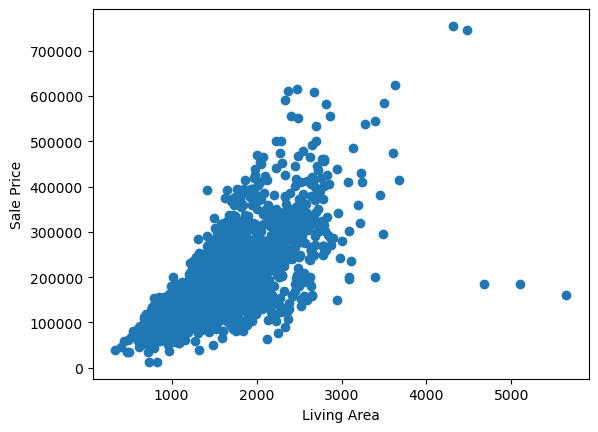

In [23]:
plt.scatter(data["Gr Liv Area"], data["SalePrice"])
plt.xlabel("Living Area")
plt.ylabel("Sale Price")
plt.show()

In [24]:
print(data["MS Zoning"].head())
print(data["Neighborhood"].head())

0    5
1    4
2    5
3    5
4    5
Name: MS Zoning, dtype: int64
0    15
1    15
2    15
3    15
4     8
Name: Neighborhood, dtype: int64


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
score = model.score(X_test, y_test)

print(score)

0.7581398402538874


In [34]:
prediction = model.predict([[
    20,      # MS SubClass
    3,       # MS Zoning (encoded)
    8000,    # Lot Area
    10,      # Neighborhood (encoded)
    7,       # Overall Qual
    2005,    # Year Built
    1800,    # Gr Liv Area
    1,       # Bsmt Full Bath
    2,       # Full Bath
    3,       # Bedroom AbvGr
    2,       # Garage Cars
    500      # Garage Area
]])
print(prediction)

[248270.50545096]


C:\Users\visha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [39]:
pickle.dump(
    model,
    open("model.pkl","wb")
)